In [ ]:
!pip install onnx
!pip install onnxscript
!pip install medpy
!pip install onnxruntime
!pip install onnx2tf

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            # Camada 1
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Camada 2
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)


class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.reduce_channels = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x1 = self.reduce_channels(x1)
        x = torch.cat([x1, x2], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, num_classes, base_filters=32):
        super().__init__()

        f1 = base_filters
        f2 = f1 * 2
        f3 = f2 * 2
        f4 = f3 * 2
        f5 = f4 * 2

        self.down_convolution_1 = DownSample(in_channels, f1)
        self.down_convolution_2 = DownSample(f1, f2)
        self.down_convolution_3 = DownSample(f2, f3)
        self.down_convolution_4 = DownSample(f3, f4)

        self.bottle_neck = nn.Sequential(
            DoubleConv(f4, f5),
            nn.Dropout2d(0.3)
        )

        self.up_convolution_1 = UpSample(f5, f4)
        self.up_convolution_2 = UpSample(f4, f3)
        self.up_convolution_3 = UpSample(f3, f2)
        self.up_convolution_4 = UpSample(f2, f1)

        self.out = nn.Conv2d(in_channels=f1, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out

In [ ]:
model_name = "unet_01_04"

torch_model = UNet(in_channels=1, num_classes=1, base_filters=8)
state_dict = torch.load(model_name+".pth", map_location=torch.device('cpu'))
torch_model.load_state_dict(state_dict)

torch_model.eval()

dummy_input = torch.randn(1, 1, 256, 256)

torch.onnx.export(
    torch_model,                  # O modelo
    dummy_input,            # O input de exemplo
    model_name+".onnx",            # Onde salvar
    export_params=True,     # Armazena os pesos treinados dentro do arquivo
    opset_version=11,       # Versão do ONNX (11 é bem compatível)
    do_constant_folding=True, # Otimização
    input_names=['input'],   # Nome da entrada no ONNX
    output_names=['output'], # Nome da saída no ONNX
)
print("Sucesso!")


4 modelos carregados
Encontrados 2 arquivos para testar
patient0451_2CH_frame0.pt | UNet 16 pth -> 484.77 ms | Dice: 0.9448 | HD95: 5.8310
patient0451_2CH_frame0.pt | UNet 16 ONNX -> 141.09 ms | Dice: 0.9448 | HD95: 5.8310
patient0451_2CH_frame0.pt | UNet 8 pth -> 87.79 ms | Dice: 0.9350 | HD95: 6.3246
patient0451_2CH_frame0.pt | UNet 8 ONNX -> 45.77 ms | Dice: 0.9350 | HD95: 6.3246


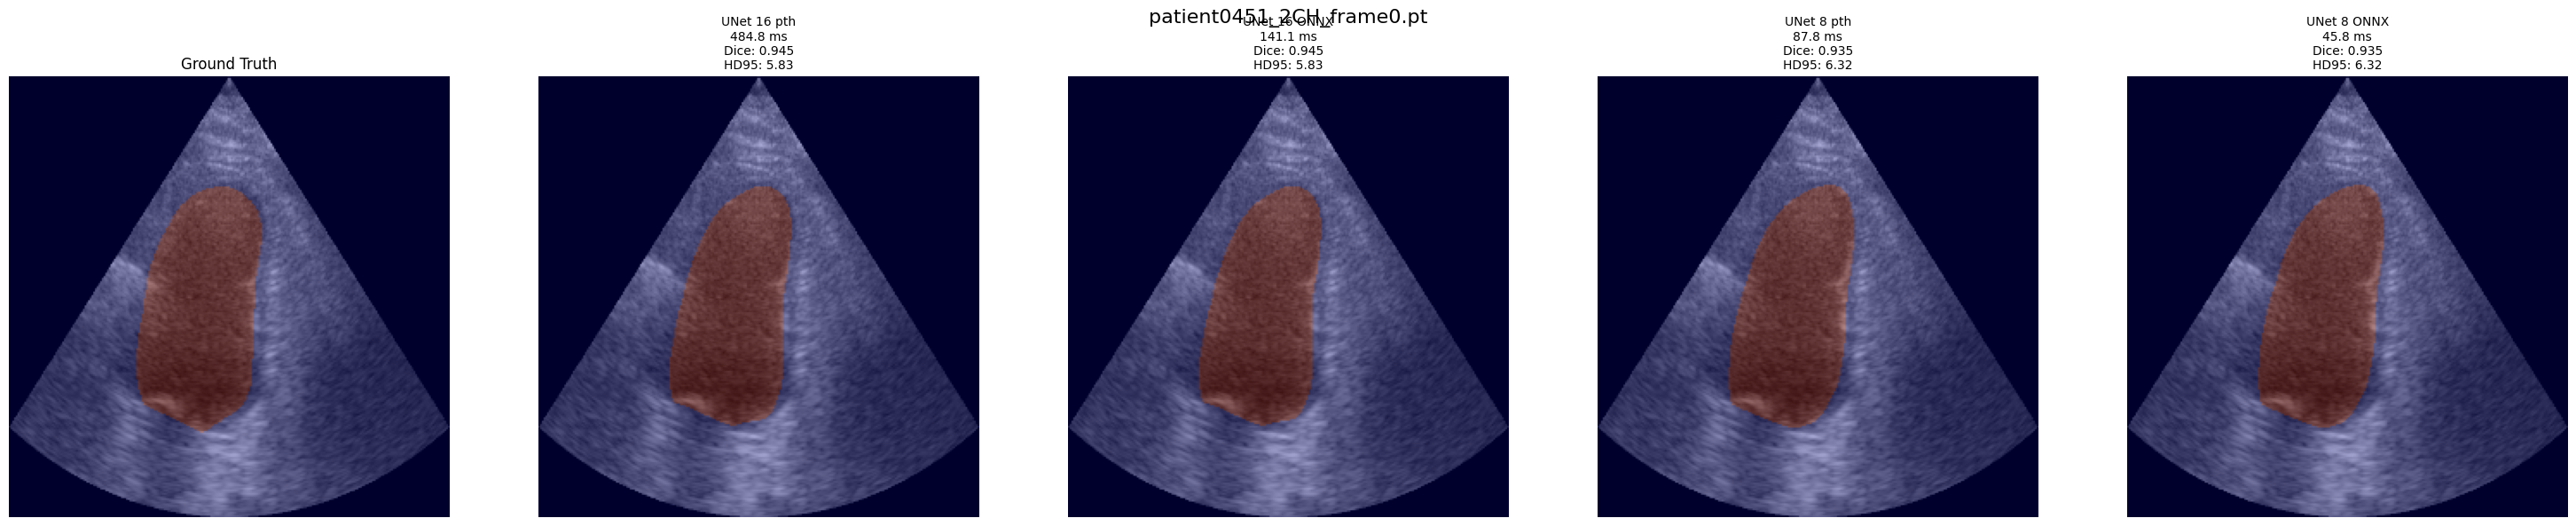

patient0451_2CH_frame1.pt | UNet 16 pth -> 201.72 ms | Dice: 0.9282 | HD95: 6.3246
patient0451_2CH_frame1.pt | UNet 16 ONNX -> 155.89 ms | Dice: 0.9282 | HD95: 6.3246
patient0451_2CH_frame1.pt | UNet 8 pth -> 77.99 ms | Dice: 0.9277 | HD95: 7.0711
patient0451_2CH_frame1.pt | UNet 8 ONNX -> 49.66 ms | Dice: 0.9277 | HD95: 7.0711


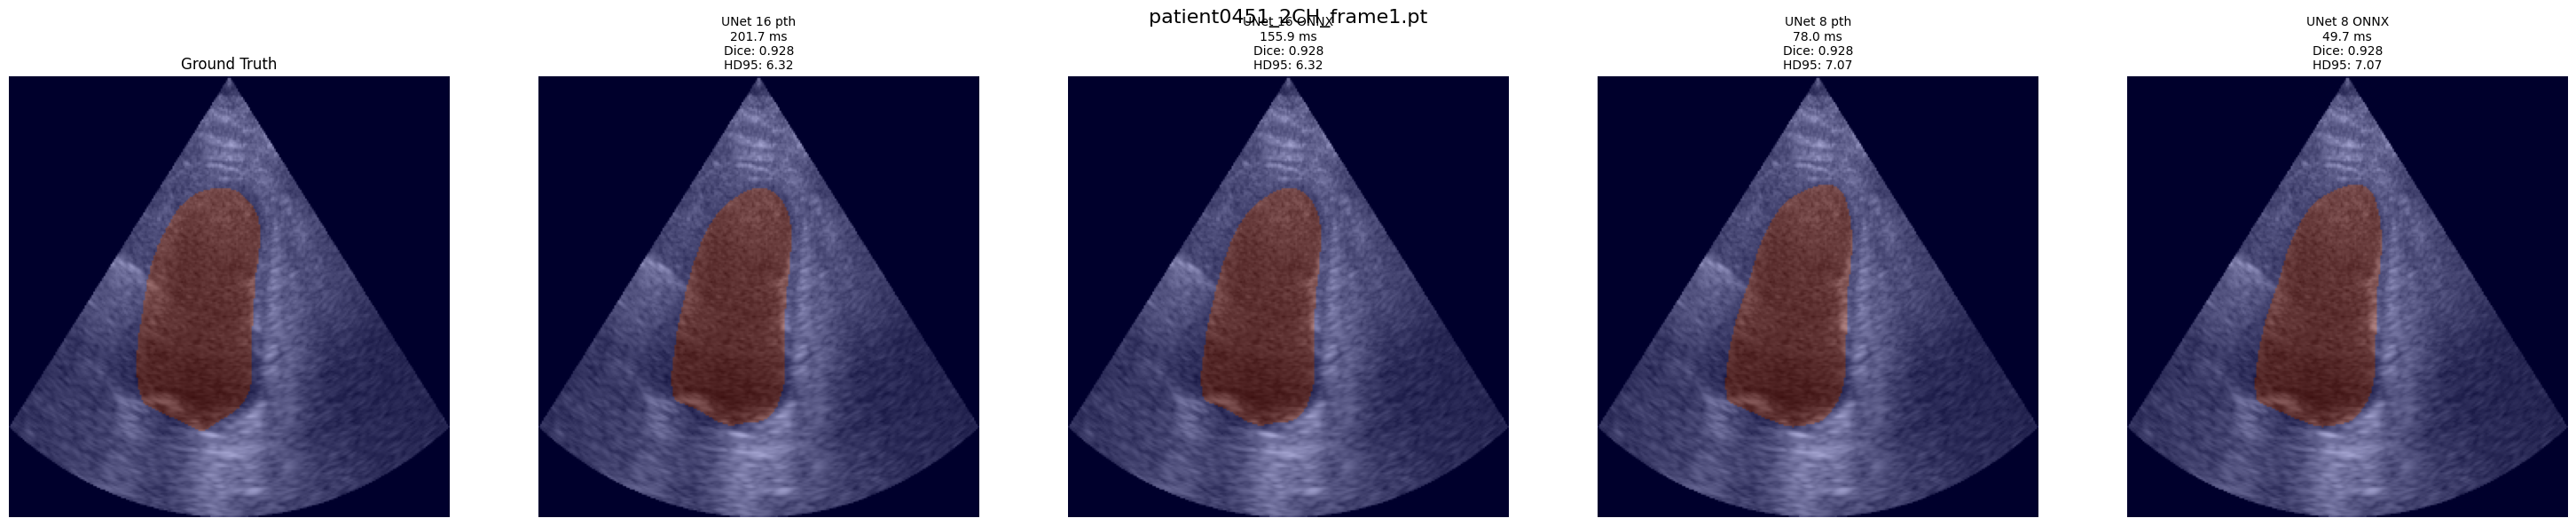

In [ ]:
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort
from medpy.metric.binary import dc, hd95


# =========================
# CONFIGURAÇÕES
# =========================

MODEL_CONFIGS = [
    {
        "name": "UNet 16 pth",
        "path": "unet_31_03.pth",
        "base_filters": 16,
        "is_onnx": False # Nova flag
    },
    {
        "name": "UNet 16 ONNX",
        "path": "unet_31_03.onnx",
        "is_onnx": True # Nova flag
    },
    {
        "name": "UNet 8 pth",
        "path": "unet_01_04.pth",
        "base_filters": 8,
        "is_onnx": False # Nova flag
    },
    {
        "name": "UNet 8 ONNX",
        "path": "unet_01_04.onnx",
        "is_onnx": True # Nova flag
    },

]

TEST_FOLDER = r"teste/"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

# Função auxiliar para o ONNX
def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

# =========================
# CARREGA TODOS OS MODELOS
# =========================

models = []

for config in MODEL_CONFIGS:
    is_onnx = config.get("is_onnx", False)

    if is_onnx:
        # Carregamento ONNX
        session = ort.InferenceSession(config["path"])
        input_name = session.get_inputs()[0].name

        models.append({
            "name": config["name"],
            "model": session,
            "is_onnx": True,
            "input_name": input_name # Guardamos o nome do input dinamicamente
        })
    else:
        # Carregamento PyTorch Clássico
        model = UNet(
            in_channels=1,
            num_classes=1,
            base_filters=config["base_filters"]
        ).to(DEVICE)

        state_dict = torch.load(config["path"], map_location=DEVICE)
        model.load_state_dict(state_dict)
        model.eval()

        models.append({
            "name": config["name"],
            "model": model,
            "is_onnx": False
        })

print(f"{len(models)} modelos carregados")

# =========================
# LISTA TODOS OS ARQUIVOS
# =========================

all_files = sorted([
    f for f in os.listdir(TEST_FOLDER)
    if f.endswith(".pt")
])

print(f"Encontrados {len(all_files)} arquivos para testar")

# =========================
# LOOP DE TESTE
# =========================

for file_name in all_files:
    file_path = os.path.join(TEST_FOLDER, file_name)

    sample = torch.load(file_path, map_location="cpu")

    img = sample["img"]      # [1, H, W]
    gt_mask = sample["mask"] # [1, H, W]

    img_np = img.squeeze().numpy()
    gt_mask_np = gt_mask.squeeze().numpy()

    gt_bool = gt_mask_np.astype(bool)

    # Tensor para o PyTorch
    input_tensor = img.unsqueeze(0).to(DEVICE)  # [1,1,H,W]
    # Array para o ONNX
    input_array = input_tensor.cpu().numpy()

    predictions = []

    # =========================
    # INFERÊNCIA DE TODOS MODELOS
    # =========================

    for model_info in models:
        model = model_info["model"]
        model_name = model_info["name"]
        is_onnx = model_info["is_onnx"]

        start_time = time.perf_counter()

        if is_onnx:
            # Inferência ONNX
            input_name = model_info["input_name"]

            # O output do ONNX é uma lista, pegamos o índice 0
            output = model.run(None, {input_name: input_array})[0]

            # Aplica a ativação Sigmoid no NumPy
            output = sigmoid_np(output)

            pred_mask = np.squeeze(output)

        else:
            # Inferência PyTorch
            with torch.no_grad():
                output = model(input_tensor)
                output = torch.sigmoid(output)

                if DEVICE == "cuda":
                    torch.cuda.synchronize()

            pred_mask = output.squeeze().cpu().numpy()

        # Tempo calculado de forma uniforme para ambos
        inference_time = (time.perf_counter() - start_time) * 1000

        pred_mask_binary = (pred_mask > THRESHOLD).astype(np.uint8)
        pred_bool = pred_mask_binary.astype(bool)

        # =========================
        # MÉTRICAS
        # =========================

        dice_value = dc(pred_bool, gt_bool)

        if pred_bool.sum() == 0 and gt_bool.sum() == 0:
            hd95_value = 0.0
        elif pred_bool.sum() == 0 or gt_bool.sum() == 0:
            hd95_value = np.nan
        else:
            hd95_value = hd95(pred_bool, gt_bool)

        predictions.append({
            "name": model_name,
            "mask": pred_mask_binary,
            "time": inference_time,
            "dice": dice_value,
            "hd95": hd95_value
        })

        print(
            f"{file_name} | {model_name} -> "
            f"{inference_time:.2f} ms | "
            f"Dice: {dice_value:.4f} | "
            f"HD95: {hd95_value:.4f}"
        )

    # =========================
    # PLOT
    # =========================

    total_plots = 1 + len(predictions)

    fig, axes = plt.subplots(
        1,
        total_plots,
        figsize=(6 * total_plots, 6)
    )

    if total_plots == 1:
        axes = [axes]

    # Ground Truth
    axes[0].set_title("Ground Truth")
    axes[0].imshow(img_np, cmap="gray")
    axes[0].imshow(gt_mask_np, cmap="jet", alpha=0.35)
    axes[0].axis("off")

    # Predições dos modelos
    for idx, pred in enumerate(predictions, start=1):
        hd95_text = (
            f"{pred['hd95']:.2f}"
            if not np.isnan(pred["hd95"])
            else "NaN"
        )

        title = (
            f"{pred['name']}\n"
            f"{pred['time']:.1f} ms\n"
            f"Dice: {pred['dice']:.3f}\n"
            f"HD95: {hd95_text}"
        )

        axes[idx].set_title(title, fontsize=10)

        axes[idx].imshow(img_np, cmap="gray")
        axes[idx].imshow(pred["mask"], cmap="jet", alpha=0.35)
        axes[idx].axis("off")

    plt.suptitle(file_name, fontsize=16)
    plt.tight_layout()

    # Espera fechar antes de continuar
    plt.show(block=True)

In [ ]:
!onnx2tf -i unet_01_04.onnx -o unet_01_04_tf


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃                       ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Concat                │ 4              │ 4                │
│ Constant              │ 57             │ 57               │
│ Conv                  │ 23             │ 23               │
│ InstanceNormalization │ 18             │ 18               │
│ MaxPool               │ 4              │ 4                │
│ Relu                  │ 18             │ 18               │
│ Resize                │ 4              │ 4                │
│ Model Size            │ 1.9MiB         │ 1.7MiB           │
└───────────────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃           

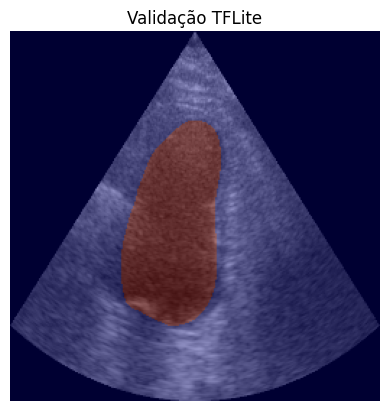

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# Carrega o modelo TFLite
interpreter = tf.lite.Interpreter(model_path="unet_29_03_tf/unet_29_03_float32.tflite")
interpreter.allocate_tensors()

# Pega os índices de entrada e saída
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepara uma imagem de teste (lembre-se do shape [1, 256, 256, 1])
# Ajuste o caminho da imagem de ultrassom
file_path = "teste/patient0451_2CH_frame0.pt"
sample = torch.load(file_path, map_location="cpu")

img_tensor = sample["img"]       # [1, H, W]
gt_mask_tensor = sample["mask"]  # [1, H, W]

# Converte para array numpy 2D [H, W]
img_np = img_tensor.squeeze().numpy()
gt_mask_np = gt_mask_tensor.squeeze().numpy()

img_resized = cv2.resize(img_np, (256, 256))

# TFLite espera batch no início e canal no final (NHWC)
input_data = np.expand_dims(img_resized, axis=0) # Fica [1, 256, 256]
input_data = np.expand_dims(input_data, axis=-1) # Fica [1, 256, 256, 1]

# Garante que é float32 (o formato nativo sem quantização)
input_data = input_data.astype(np.float32)

# Roda a inferência
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Pega a predição e tira as dimensões extras
output_data = interpreter.get_tensor(output_details[0]['index'])
pred_mask = np.squeeze(output_data)

# Aplica a Sigmoid (se o TFLite não a incluiu) e o Threshold
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

pred_mask_binary = (sigmoid(pred_mask) > 0.5).astype(np.uint8) * 255

# Plota para ver se está tudo certo
plt.imshow(img_resized, cmap='gray')
plt.imshow(pred_mask_binary, cmap='jet', alpha=0.4)
plt.title("Validação TFLite")
plt.axis('off')
plt.show()